# Client GUI Usage

The following section shows how to use the S2GOS client's GUI using
`client.show_app()` to open the GUI of the app and to interact with it.

**Important:** The code below expects that you have been given access to the S2GOS 
processing system. If not, you can also run a local test server in another terminal 
window:

```bash
s2gos-server run -- wraptile.services.local.testing:service
```
---

In [30]:
import json
from pathlib import Path

from s2gos_client.api import create_client

## Create a client instance

First, get any configuration overrides allowing us to use the S2GOS processing system.
You could also use the command `s2gos-client configure` in a terminal window.

In [31]:
def read_config(path: str | Path):
    path = Path(path)
    return json.loads(path.read_text()) if path.exists() else {}

In [32]:
# any configuration overrides
config = read_config("config.json")
# extra configuration for access the results
storage_options = read_config("storage-options.json")

Create a S2GOS client instance with your user credentials.

In [6]:
client = create_client(**config)

In [33]:
#client.login()

## Show the app

In [37]:
app = client.show_app(height=640)

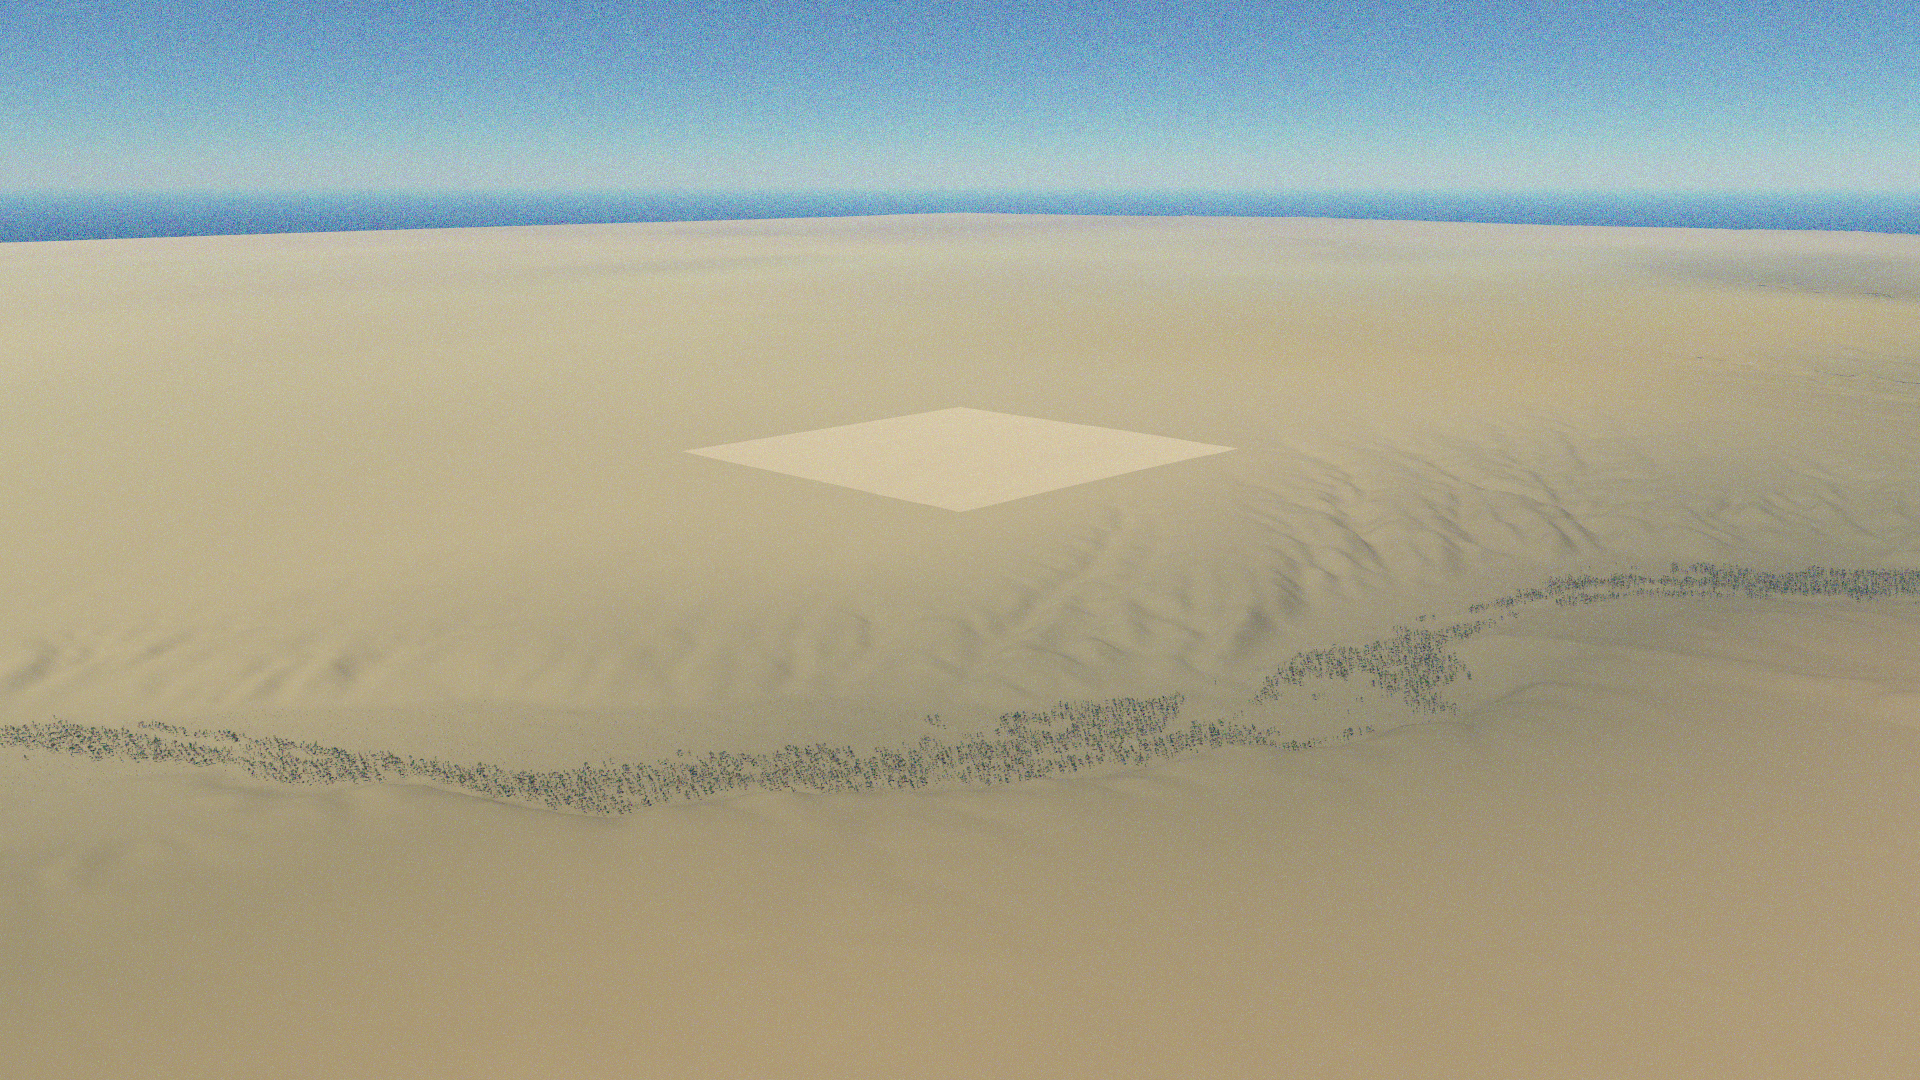

In [35]:
client.open_job_result("job_2", output_name="image", storage_options=storage_options)

In [36]:
dataset = client.open_job_result("job_2", output_name="dataset", storage_options=storage_options)
dataset

<xarray.Dataset> Size: 50MB
Dimensions:     (sza: 1, saa: 1, w: 3, y_index: 1080, x_index: 1920)
Coordinates:
  * sza         (sza) float64 8B 27.96
  * saa         (saa) float64 8B 185.9
  * w           (w) float64 24B 440.0 550.0 660.0
  * y_index     (y_index) int64 9kB 0 1 2 3 4 5 ... 1075 1076 1077 1078 1079
    y           (y_index) float64 9kB ...
  * x_index     (x_index) int64 15kB 0 1 2 3 4 5 ... 1915 1916 1917 1918 1919
    x           (x_index) float64 15kB ...
Data variables:
    irradiance  (sza, saa, w) float64 24B ...
    radiance    (w, y_index, x_index, saa, sza) float64 50MB ...
Attributes:
    backend:            eradiate
    created_at:         2026-07-31T12:53:48.073164
    description:        None
    illumination_type:  directional
    measurement_types:  []
    num_measurements:   0
    num_sensors:        1
    output_dir:         gobabeb_sentinel2/december/sim_output
    result_type:        sensor
    sensor_id:          aerial_camera
    sensor_types:       ['ground']
    simulation_name:    pnp_demo_summer